In [ ]:
wget -qO- "https://sra-pub-src-1.s3.amazonaws.com/SRR23804247/synthetic_DRS_m6a.tar.gz.1" | tar -tzf - | grep '\.fast5$' | head -n 20 > file_list.txt
 tar -xzf synthetic_DRS_unmodified.tar.gz -T unmodified.txt


guppy_basecaller -i /root/sunxh/WaveCrossMamba/result_reproduce/unmodified/ -s /root/sunxh/WaveCrossMamba/result_reproduce/unmodified_guppy --num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device "cuda:0 cuda:1 cuda:2 cuda:3"
guppy_basecaller -i /root/sunxh/WaveCrossMamba/result_reproduce/m5C -s /root/sunxh/WaveCrossMamba/contrast/m5C_guppy --num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device "cuda:0 cuda:1 cuda:2 cuda:3"


multi_to_single_fast5 -i /root/sunxh/WaveCrossMamba/contrast/m5C_guppy -s /root/sunxh/WaveCrossMamba/result_reproduce/m5C_guppy_single -t 40 --recursive √
multi_to_single_fast5 -i unmodified_guppy/ -s unmodified_guppy_single -t 40 --recursive √


tombo resquiggle --overwrite --basecall-group Basecall_1D_001 m6a_guppy_single /root/sunxh/WaveCrossMamba/result_reproduce/GSE227087_synthetic_reference.fa --processes 40 --fit-global-scale --include-event-stdev
tombo resquiggle --overwrite --basecall-group Basecall_1D_001 unmodified_guppy_single /root/sunxh/WaveCrossMamba/result_reproduce/GSE227087_synthetic_reference.fa --processes 40 --fit-global-scale --include-event-stdev √


cat /root/sunxh/WaveCrossMamba/contrast/m6a_guppy/pass/*.fastq >m6a.fastq
cat unmodified_guppy/pass/*.fastq >unmodified.fastq


minimap2 -ax map-ont /root/sunxh/WaveCrossMamba/result_reproduce/GSE227087_synthetic_reference.fa m6a.fastq > m6a.sam
minimap2 -ax map-ont /root/sunxh/WaveCrossMamba/result_reproduce/GSE227087_synthetic_reference.fa unmodified.fastq > unmodified.sam


python /root/sunxh/WaveCrossMamba/utils/fast5_signal.py -p 40 --fast5 /root/sunxh/WaveCrossMamba/result_reproduce/m6a_guppy_single --reference /root/sunxh/WaveCrossMamba/result_reproduce/GSE227087_synthetic_reference.fa --sam m6a.sam --output m6a.signal.tsv --clip=10
python /root/sunxh/WaveCrossMamba/utils/fast5_signal.py -p 40 --fast5 /root/sunxh/WaveCrossMamba/result_reproduce/unmodified_guppy_single --reference /root/sunxh/WaveCrossMamba/result_reproduce/GSE227087_synthetic_reference.fa --sam unmodified.sam --output unmodified.signal.tsv --clip=10

python /root/sunxh/WaveCrossMamba/utils/signal_features.py --signal_file /root/sunxh/WaveCrossMamba/contrast/IVT_normalA.signal.tsv --clip 10 --output /root/sunxh/WaveCrossMamba/contrast/IVT_normalA_RRACH.tsv --motif RRACH


In [3]:
import os
import pandas as pd
input_file = "/root/sunxh/m6a/IVT_m6a.signal.tsv"
output_dir = "/root/sunxh/test_result/m6a_read_length_0-1200/"
os.makedirs(output_dir, exist_ok=True)
bins = [0, 200, 400, 600, 800, 1000, 1200]  
labels = ["0-200", "200-400", "400-600", "600-800", "800-1000", "1000-1200"]
count_dict = {label: 0 for label in labels}
max_count_per_category = 4000
category_data = {label: [] for label in labels}  
with open(input_file, "r") as f:
    for line in f:
        items = line.strip().split("\t")
        if len(items) < 6:
            continue 
        read_length = len(items[5]) 
        category = None
 
        for i in range(len(bins) - 1):
            if bins[i] <= read_length < bins[i + 1]:
                category = labels[i]
                break
        if category is not None and count_dict[category] < max_count_per_category:
            category_data[category].append(line) 
            count_dict[category] += 1 

 
        if all(count >= max_count_per_category for count in count_dict.values()):
            print("所有类别已达最大数量，停止读取文件")
            break
# **写入文件**
for category, data_lines in category_data.items():
    output_filename = os.path.join(output_dir, f"reads_m6a_{category}.tsv")
    with open(output_filename, "w") as out_f:
        out_f.writelines(data_lines) 
    print(f"已保存：{output_filename}, 读取数目：{len(data_lines)}")

# **输出类别统计信息**
print("最终类别统计：")
for category, count in count_dict.items():
    print(f"{category}: {count} reads")


所有类别已达最大数量，停止读取文件
已保存：/root/sunxh/test_result/m6a_read_length_0-1200/reads_m6a_0-200.tsv, 读取数目：4000
已保存：/root/sunxh/test_result/m6a_read_length_0-1200/reads_m6a_200-400.tsv, 读取数目：4000
已保存：/root/sunxh/test_result/m6a_read_length_0-1200/reads_m6a_400-600.tsv, 读取数目：4000
已保存：/root/sunxh/test_result/m6a_read_length_0-1200/reads_m6a_600-800.tsv, 读取数目：4000
已保存：/root/sunxh/test_result/m6a_read_length_0-1200/reads_m6a_800-1000.tsv, 读取数目：4000
已保存：/root/sunxh/test_result/m6a_read_length_0-1200/reads_m6a_1000-1200.tsv, 读取数目：4000
最终类别统计：
0-200: 4000 reads
200-400: 4000 reads
400-600: 4000 reads
600-800: 4000 reads
800-1000: 4000 reads
1000-1200: 4000 reads


In [1]:
import os
import re
import random
import traceback
import numpy as np
from scipy import interpolate
from statsmodels import robust

def reverse_compliment(seq):
    """
    Generate reverse complement sequence.

    Args:
        seq (str): Origin sequence.

    Returns:
        str: Reverse complement sequence.
    """
    seq = seq.replace("A", "t")
    seq = seq.replace("G", "c")
    seq = seq.replace("C", "g")
    seq = seq.replace("T", "a")
    seq = seq.replace("N", "N")
    return seq[::-1].upper()

def interp(x):
    """
    Interpolate and resample the current signal to make each base correspond to the same length of current signal.

    Args:
        x (float list): Origin current signal.

    Returns:
        float list: Interpolated signal.
    """
    l = len(x)
    y = x
    x = np.linspace(0, l - 1, l)
    f = interpolate.interp1d(x, y, kind='slinear')
    x_new = np.linspace(0, l - 1, 100)
    y_new = f(x_new)
    y_new = np.around(y_new, 4)
    return y_new.tolist()

def convert_base_name(base_name):
    """
    Converts a base name into a regular expression pattern.

    Args:
        base_name (str): Input base name to be converted.

    Returns:
        str: Regular expression pattern representing the converted base name.
    """
    merge_bases = {
        'A': 'A',
        'C': 'C',
        'G': 'G',
        'T': 'T',
        'M': '[AC]',
        'V': '[ACG]',
        'R': '[AG]',
        'H': '[ACT]',
        'W': '[AT]',
        'D': '[AGT]',
        'S': '[CG]',
        'B': '[CGT]',
        'Y': '[CT]',
        'N': '[ACGT]',
        'K': '[GT]'
    }
    pattern = ''
    for base in base_name:
        pattern += merge_bases.get(base, base)
    return pattern

def extract_5mer_features(signal_file, clip, output, motif):
    """
    Extracts features from a signal file.

    Args:
        signal_file (str): Path to the signal file.
        clip (int): Base clip at both ends.
        output (str): Path to the output file.
        motif (str): Sequence motif.
    """
    base_quality_dict = dict()
    kmer_filter = convert_base_name(motif)
    
    out = open(output, "w")

    count = 0
    scaling = "median_mad"
    
    with open(signal_file) as f:
        for line in f:
            try:
                if count >= 4e3: 
                    print(f"Processing stopped as count reached {count}.")
                    break
                line = line.rstrip()
                items = line.split("\t")
                read_id = items[0]
                chr = items[1]
                start = int(items[2])
                reference_sequence = items[3]
                base_quality_list = items[4].split("|")
                sequence = line.split("\t")[5]
                signal_string = line.split("\t")[6]
                raw_signal = [base_signal_string.split("*") for base_signal_string in signal_string.split("|")] 
                full_length_signal = np.array([x for x in re.split('\*|\|', signal_string)], dtype=int) 
                full_length_signal_min = min(full_length_signal)
                full_length_signal_max = max(full_length_signal)
                full_length_signal_uniq = np.unique(full_length_signal)
                full_length_mean = np.mean(full_length_signal)
                full_length_std = np.std(full_length_signal)
                
                for index in range(clip, len(sequence) - clip):
                    kmer_sequence = sequence[index - 2:index + 3]
                    if len([x.start() for x in re.finditer(kmer_filter, kmer_sequence)]) == 0:
                        continue
                    if sequence[index - 2:index + 3] != reference_sequence[index - 2:index + 3]:
                        continue

                    kmer_raw_signal = raw_signal[index - 2:index + 3]
                    kmer_raw_signal = [np.array(x, dtype=float) for x in kmer_raw_signal]
                    
 
                    if scaling == "min_max":
                        kmer_raw_signal = [(x - full_length_signal_min) / (full_length_signal_max - full_length_signal_min) for x in kmer_raw_signal]
                    elif scaling == "zscore":
                        kmer_raw_signal = [(x - full_length_mean) / full_length_std for x in kmer_raw_signal]
                    elif scaling == "median_mad":
                        kmer_raw_signal = [(x - np.median(full_length_signal_uniq)) / robust.mad(full_length_signal_uniq) for x in kmer_raw_signal]
                    
                    mean = [np.round(np.mean(x), 3) for x in kmer_raw_signal]
                    std = [np.round(np.std(x), 3) for x in kmer_raw_signal]
                    median = [np.round(np.median(x), 3) for x in kmer_raw_signal]
                    length = [len(x) for x in kmer_raw_signal]
                    kmer_base_quality = base_quality_list[index - 2:index + 3]
                    
                    for i in range(5):
                        kmer_raw_signal[i] = interp(kmer_raw_signal[i])
                        
                    line = "%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\t%s\n" % (
                        read_id, chr, start + index, kmer_sequence,
                        "|".join([str(x) for x in mean]),
                        "|".join([str(x) for x in std]),
                        "|".join([str(x) for x in median]),
                        "|".join([str(x) for x in length]),
                        "|".join([str(x) for x in kmer_base_quality]),
                        "|".join([str(x) for x in kmer_raw_signal[0]]),
                        "|".join([str(x) for x in kmer_raw_signal[1]]),
                        "|".join([str(x) for x in kmer_raw_signal[2]]),
                        "|".join([str(x) for x in kmer_raw_signal[3]]),
                        "|".join([str(x) for x in kmer_raw_signal[4]])
                    )
                    
                    file_name = "%s_%s_%s_%s.feature" % (read_id, chr, start + index, kmer_sequence)
                    count += 1
                
                    if count % 1e4 == 0:
                        print(count)

                    out.writelines(line)
                    
            except Exception as e:
                print(traceback.print_exc())
    print(f"Total features extracted: {count}")
    print("done!")
    out.close()


In [ ]:
import os
import pandas as pd
os.chdir("/root/sunxh/WaveCrossMamba") 
# 设置输入目录和输出目录
input_dir = "/root/sunxh/test_result/m6a_read_length_0-1200"
output_dir = "/root/sunxh/test_result/m6a_read_length_0-1200_features"

# 确保输出目录存在
os.makedirs(output_dir, exist_ok=True)
clip = 10 
motif = "NNANN"  
        
# 遍历输入目录下的所有文件
for filename in os.listdir(input_dir):
 
    if filename.endswith(".tsv"):
 
        file_path = os.path.join(input_dir, filename)
        
 
        df = pd.read_csv(file_path, sep="\t", header=None)
        row_count = len(df)
        
 
        print(f"文件: {filename}，读取数目: {row_count}")
        
 
        output_filename = f"{filename.replace('.tsv', '')}_features.tsv"
        output_file_path = os.path.join(output_dir, output_filename)
 
        extract_5mer_features(file_path, clip, output_file_path, motif)
        
        print(f"已处理并保存：{output_file_path}")


文件: reads_unmodified_200-400.tsv，读取数目: 4000
Processing stopped as count reached 4015.
Total features extracted: 4015
done!
已处理并保存：/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_200-400_features.tsv
文件: reads_unmodified_600-800.tsv，读取数目: 4000
Processing stopped as count reached 4049.
Total features extracted: 4049
done!
已处理并保存：/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_600-800_features.tsv
文件: reads_unmodified_400-600.tsv，读取数目: 4000
Processing stopped as count reached 4021.
Total features extracted: 4021
done!
已处理并保存：/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_400-600_features.tsv
文件: reads_m6a_1000-1200.tsv，读取数目: 4000
Processing stopped as count reached 4179.
Total features extracted: 4179
done!
已处理并保存：/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_1000-1200_features.tsv
文件: reads_m6a_400-600.tsv，读取数目: 4000
Processing stopped as count reached 4081.
Total features extracted: 4081
done

In [ ]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from torch.utils.data import DataLoader
import numpy as np
import torch
import sys
from collections import defaultdict
from sklearn.model_selection import KFold
import os
import multiprocessing
import argparse
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, classification_report, confusion_matrix
from tqdm import tqdm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
os.chdir("/root/sunxh/WaveCrossMamba") 
print(os.getcwd()) 
from model.model import WaveCrossMamba,AnomalyDetectionModel
from utils.dataloader import UnlabeledDataset,SupervisedDataset,load_data_supervised,load_data_unsupervised
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from train_test.anomaly_detection import test_model
import torch.multiprocessing as mp
torch.cuda.empty_cache() 



/root/sunxh/WaveCrossMamba
测试过程。


In [27]:

print("测试数据加载完成。") 
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/root/sunxh/WaveCrossMamba/save_result/pre_no_pretraining_m6a.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/root/sunxh/WaveCrossMamba/save_result/fine_no_pretraining_m6a.pth', map_location=device))
print("开始评估异常检测模型...")

测试数据加载完成。
开始评估异常检测模型...


In [4]:
def plot_roc_pr_curves(fpr, tpr, roc_auc, precision, recall, pr_auc, title=""):

    plt.figure(figsize=(12, 5))

 
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve {title}')
    plt.legend(loc="lower right")

 
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='red', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve {title}')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

In [5]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc, roc_curve

def test_model(pretrain_model, model, test_loader, device):
    model.to(device)
    pretrain_model.to(device)
    all_labels = []
    all_preds = []
    all_probs = []

    model.eval()
    pretrain_model.eval()
    with torch.no_grad():
        for batch_idx, (data, rog, targets) in enumerate(test_loader):
            x, kmer, mean, std, intense, dwell, base_quality = data

 
            x = x.to(device)
            kmer = kmer.to(device)
            mean = mean.to(device)
            std = std.to(device)
            intense = intense.to(device)
            dwell = dwell.to(device)
            base_quality = base_quality.to(device)
            targets = targets.to(device)

            if targets.dtype != torch.long:
                targets = targets.long()
            x = x.unsqueeze(2)

            logits, ff = pretrain_model(x, kmer, mean, std, intense, dwell, base_quality)
            y_pred = model(logits).to(device)
            probs = torch.softmax(y_pred, dim=1).cpu().numpy()[:, 1] 

 
            all_labels.extend(targets.cpu().numpy())
            all_preds.extend(np.argmax(y_pred.cpu().numpy(), axis=1)) 
            all_probs.extend(probs)
    
 
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

 
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel() 

 
    roc_auc = roc_auc_score(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)
    fpr_all, tpr, _ = roc_curve(all_labels, all_probs)

 
    f1_score = (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) > 0 else 0
    positivity_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_score = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_score = tp / (tp + fn) if (tp + fn) > 0 else 0

 
    print("\nPerformance on all samples:")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))
    print(f"Precision: {precision_score}")
    print(f"Recall: {recall_score}")
    print(f"F1 Score: {f1_score}")
    print(f"ROC-AUC: {roc_auc}")
    print(f"PR-AUC: {pr_auc}")
    print(f"Positivity Rate: {positivity_rate}")

    return fpr_all, tpr, precision, recall, roc_auc, pr_auc


[('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_0-200_features.tsv', 1), ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_0-200_features.tsv', 0)]
成功
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_0-200_features.tsv 中加载了 500 条数据
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_0-200_features.tsv 中加载了 500 条数据
总数据量: 1000
训练集大小: 1000
验证集大小: 0



Performance on all samples:
Confusion Matrix:
[[433  67]
 [147 353]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.87      0.80       500
           1       0.84      0.71      0.77       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.78      1000
weighted avg       0.79      0.79      0.78      1000

Precision: 0.8404761904761905
Recall: 0.706
F1 Score: 0.7673913043478261
ROC-AUC: 0.8879239999999999
PR-AUC: 0.8778425204019898
Positivity Rate: 0.706


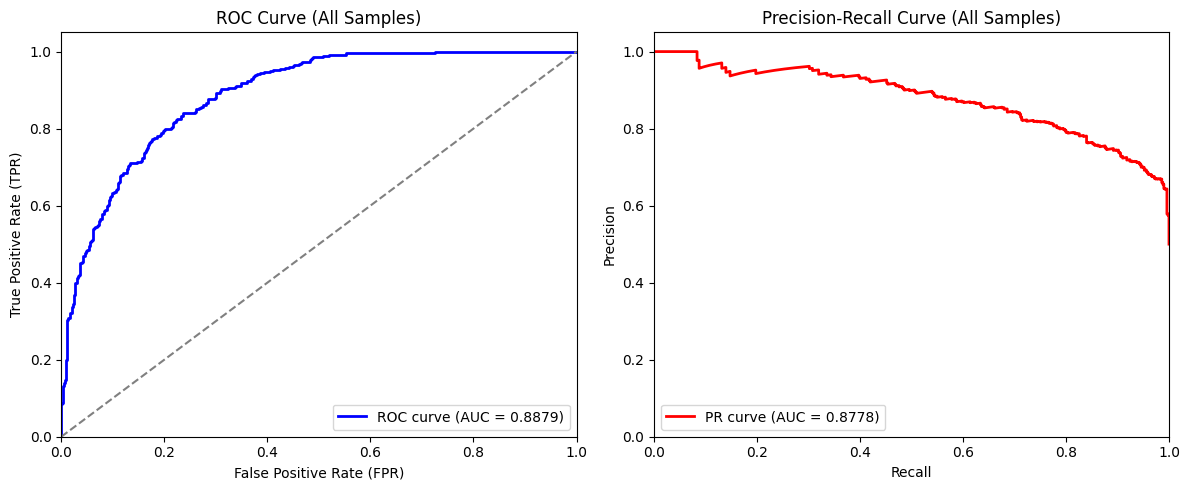

✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'


In [7]:
data_files = [
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_0-200_features.tsv', 1), 
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_0-200_features.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(500) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
# 创建 SupervisedDataset
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
# 创建 test_loader，包含所有测试样本
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
# 计算所有样本的 ROC & PR 曲线
(fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all) = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
# 绘制所有样本的 ROC & PR 曲线
plot_roc_pr_curves(fpr_all, tpr_all, roc_auc_all, precision_all, recall_all, pr_auc_all, title="(All Samples)")
# 绘制高置信度样本的 ROC & PR 曲线
import pandas as pd
# 生成 DataFrame 并保存
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
# 保存为 CSV 文件
df_roc.to_csv("/root/sunxh/test_result/roc_m6a_0-200.csv", sep=",", index=False)
df_pr.to_csv("/root/sunxh/test_result/pr_m6a_0-200.csv", sep=",", index=False)
# 输出文件保存成功信息
print("✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'")


[('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_200-400_features.tsv', 1), ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_200-400_features.tsv', 0)]
成功
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_200-400_features.tsv 中加载了 1300 条数据
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_200-400_features.tsv 中加载了 1300 条数据
总数据量: 2600
训练集大小: 2600
验证集大小: 0



Performance on all samples:
Confusion Matrix:
[[1156  144]
 [ 341  959]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83      1300
           1       0.87      0.74      0.80      1300

    accuracy                           0.81      2600
   macro avg       0.82      0.81      0.81      2600
weighted avg       0.82      0.81      0.81      2600

Precision: 0.8694469628286491
Recall: 0.7376923076923076
F1 Score: 0.7981689554723262
ROC-AUC: 0.9132745562130178
PR-AUC: 0.9068631049595447
Positivity Rate: 0.7376923076923076


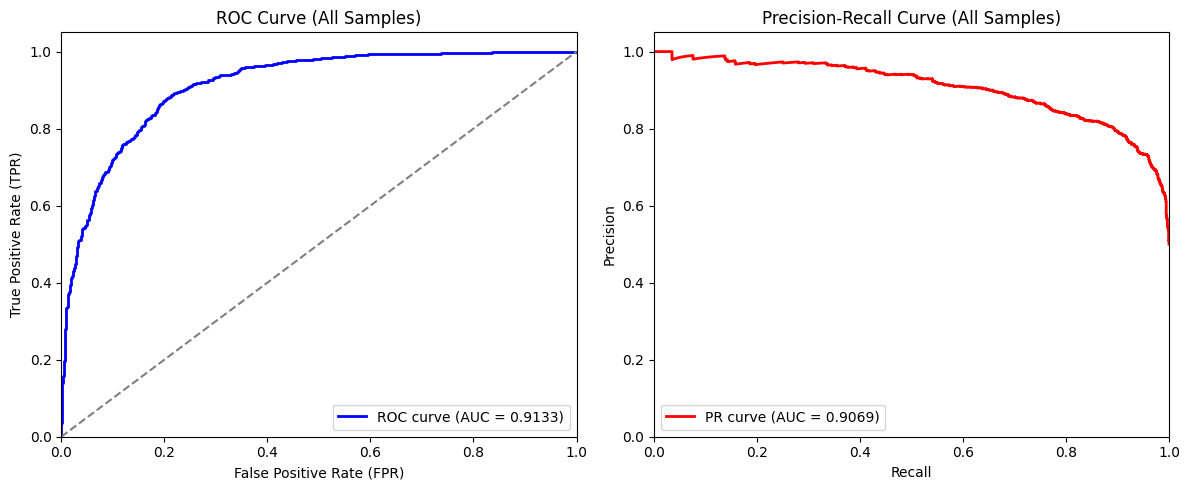

✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'


In [8]:
data_files = [
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_200-400_features.tsv', 1), 
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_200-400_features.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(1300) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
# 创建 SupervisedDataset
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
# 创建 test_loader，包含所有测试样本
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
# 计算所有样本的 ROC & PR 曲线
(fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all) = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
# 绘制所有样本的 ROC & PR 曲线
plot_roc_pr_curves(fpr_all, tpr_all, roc_auc_all, precision_all, recall_all, pr_auc_all, title="(All Samples)")
# 绘制高置信度样本的 ROC & PR 曲线
import pandas as pd
# 生成 DataFrame 并保存
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
# 保存为 CSV 文件
df_roc.to_csv("/root/sunxh/test_result/roc_m6a_200-400.csv", sep=",", index=False)
df_pr.to_csv("/root/sunxh/test_result/pr_m6a_200-400.csv", sep=",", index=False)
# 输出文件保存成功信息
print("✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'")

[('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_400-600_features.tsv', 1), ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_400-600_features.tsv', 0)]
成功
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_400-600_features.tsv 中加载了 4000 条数据
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_400-600_features.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0

Performance on all samples:
Confusion Matrix:
[[3602  398]
 [ 913 3087]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85      4000
           1       0.89      0.77      0.82      4000

    accuracy                           0.84      8000
   macro avg       0.84      0.84      0.84      8000
weighted avg       0.84      0.84      0.84      8000

Precision: 0.8857962697274031
Recall: 0.77175
F1 Score: 0.8248496993987976
ROC-AUC: 0.9255537500000001
PR-AUC: 0.92063667928441

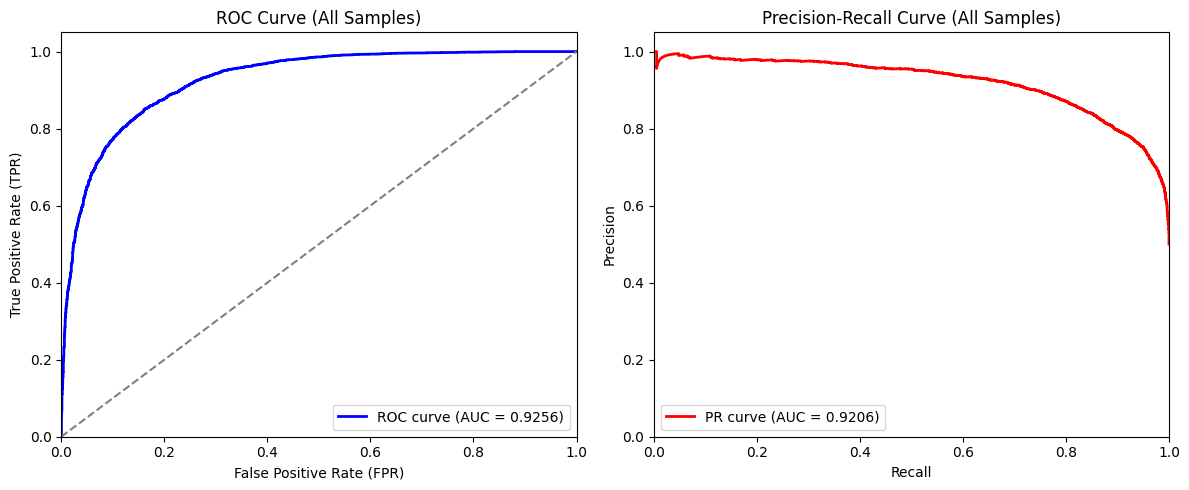

✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'


In [21]:
data_files = [
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_400-600_features.tsv', 1), 
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_400-600_features.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(4000) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
# 创建 SupervisedDataset
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
# 创建 test_loader，包含所有测试样本
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
# 计算所有样本的 ROC & PR 曲线
(fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all) = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
# 绘制所有样本的 ROC & PR 曲线
plot_roc_pr_curves(fpr_all, tpr_all, roc_auc_all, precision_all, recall_all, pr_auc_all, title="(All Samples)")
# 绘制高置信度样本的 ROC & PR 曲线
import pandas as pd
# 生成 DataFrame 并保存
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
# 保存为 CSV 文件
df_roc.to_csv("/root/sunxh/test_result/roc_m6a_400-600.csv", sep=",", index=False)
df_pr.to_csv("/root/sunxh/test_result/pr_m6a_400-600.csv", sep=",", index=False)
# 输出文件保存成功信息
print("✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'")

[('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_600-800_features.tsv', 1), ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_600-800_features.tsv', 0)]
成功
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_600-800_features.tsv 中加载了 4000 条数据
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_600-800_features.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0

Performance on all samples:
Confusion Matrix:
[[3630  370]
 [ 924 3076]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85      4000
           1       0.89      0.77      0.83      4000

    accuracy                           0.84      8000
   macro avg       0.84      0.84      0.84      8000
weighted avg       0.84      0.84      0.84      8000

Precision: 0.8926291352292514
Recall: 0.769
F1 Score: 0.8262154176739189
ROC-AUC: 0.9323403124999999
PR-AUC: 0.9261687648676619

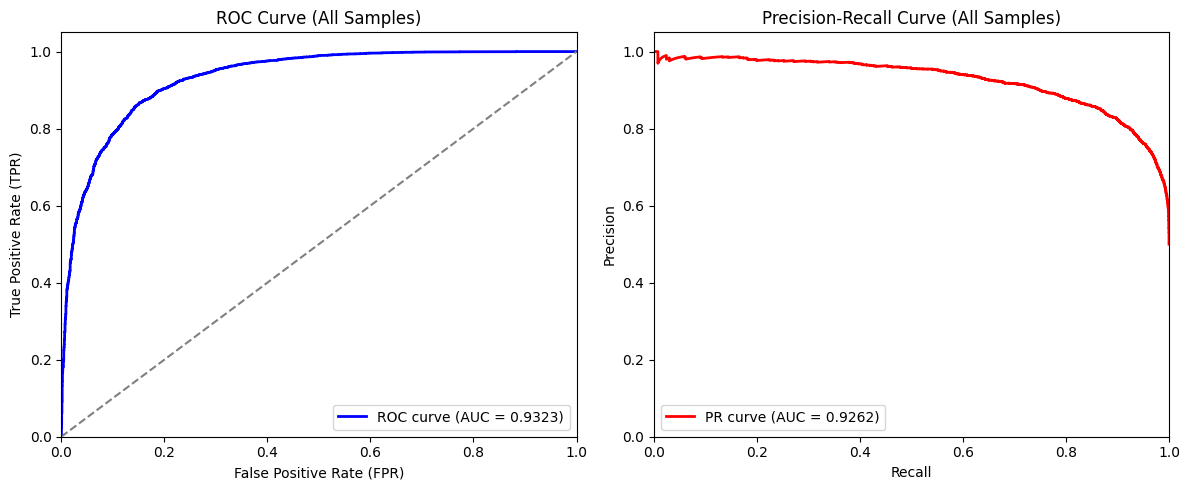

✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'


In [20]:
data_files = [
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_600-800_features.tsv', 1), 
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_600-800_features.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(4000) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
# 创建 SupervisedDataset
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
# 创建 test_loader，包含所有测试样本
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
# 计算所有样本的 ROC & PR 曲线
(fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all)= test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
# 绘制所有样本的 ROC & PR 曲线
plot_roc_pr_curves(fpr_all, tpr_all, roc_auc_all, precision_all, recall_all, pr_auc_all, title="(All Samples)")
# 绘制高置信度样本的 ROC & PR 曲线
import pandas as pd
# 生成 DataFrame 并保存
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
# 保存为 CSV 文件
df_roc.to_csv("/root/sunxh/test_result/roc_m6a_600-800.csv", sep=",", index=False)
df_pr.to_csv("/root/sunxh/test_result/pr_m6a_600-800.csv", sep=",", index=False)
# 输出文件保存成功信息
print("✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'")

[('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_800-1000_features.tsv', 1), ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_800-1000_features.tsv', 0)]
成功
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_800-1000_features.tsv 中加载了 1000 条数据
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_800-1000_features.tsv 中加载了 1000 条数据
总数据量: 2000
训练集大小: 2000
验证集大小: 0



Performance on all samples:
Confusion Matrix:
[[898 102]
 [203 797]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1000
           1       0.89      0.80      0.84      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Precision: 0.8865406006674083
Recall: 0.797
F1 Score: 0.8393891521853607
ROC-AUC: 0.933925
PR-AUC: 0.9341046665876036
Positivity Rate: 0.797


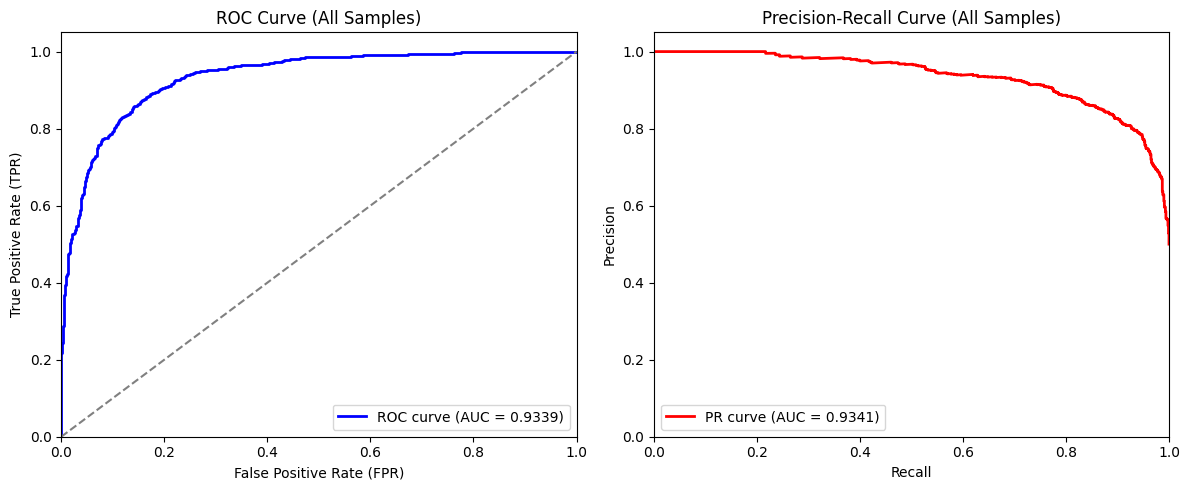

✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'


In [25]:
data_files = [
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_800-1000_features.tsv', 1), 
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_800-1000_features.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(1000) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
# 创建 SupervisedDataset
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
# 创建 test_loader，包含所有测试样本
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
# 计算所有样本的 ROC & PR 曲线
(fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all) = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
# 绘制所有样本的 ROC & PR 曲线
plot_roc_pr_curves(fpr_all, tpr_all, roc_auc_all, precision_all, recall_all, pr_auc_all, title="(All Samples)")
# 绘制高置信度样本的 ROC & PR 曲线
import pandas as pd
# 生成 DataFrame 并保存
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
# 保存为 CSV 文件
df_roc.to_csv("/root/sunxh/test_result/roc_m6a_800-1000.csv", sep=",", index=False)
df_pr.to_csv("/root/sunxh/test_result/pr_m6a_800-1000.csv", sep=",", index=False)
# 输出文件保存成功信息
print("✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'")

[('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_1000-1200_features.tsv', 1), ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_1000-1200_features.tsv', 0)]
成功
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_1000-1200_features.tsv 中加载了 1000 条数据
文件 /root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_1000-1200_features.tsv 中加载了 1000 条数据
总数据量: 2000
训练集大小: 2000
验证集大小: 0

Performance on all samples:
Confusion Matrix:
[[907  93]
 [209 791]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1000
           1       0.89      0.79      0.84      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Precision: 0.8947963800904978
Recall: 0.791
F1 Score: 0.8397027600849257
ROC-AUC: 0.940104
PR-AUC: 0.9369644061346932
Posit

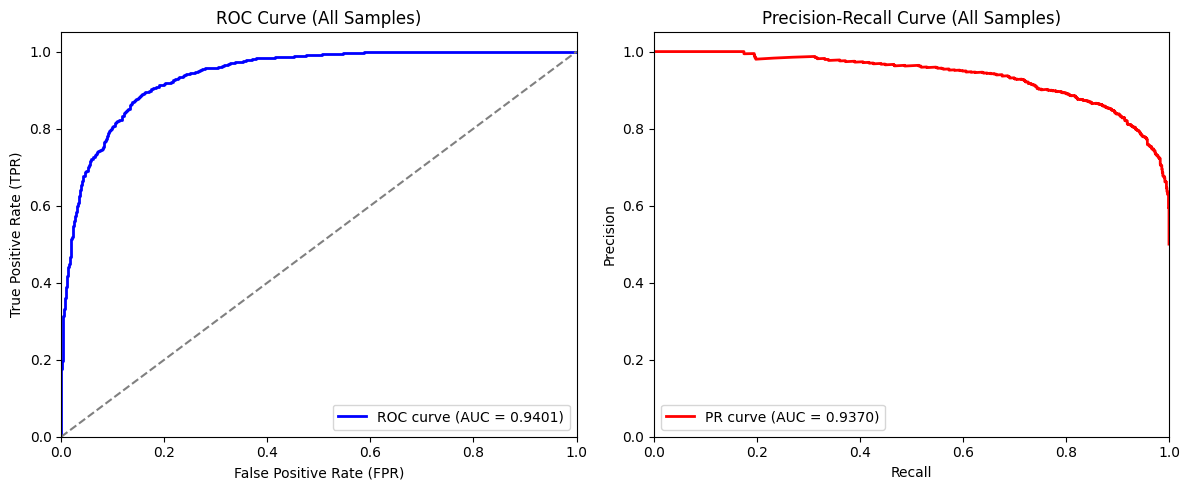

✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'


In [29]:
data_files = [
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_m6a_1000-1200_features.tsv', 1), 
    ('/root/sunxh/test_result/m6a_read_length_0-1200_features/reads_unmodified_1000-1200_features.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(1000) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
# 创建 SupervisedDataset
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
# 创建 test_loader，包含所有测试样本
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
# 计算所有样本的 ROC & PR 曲线
(fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all)= test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
# 绘制所有样本的 ROC & PR 曲线
plot_roc_pr_curves(fpr_all, tpr_all, roc_auc_all, precision_all, recall_all, pr_auc_all, title="(All Samples)")
# 绘制高置信度样本的 ROC & PR 曲线
import pandas as pd
# 生成 DataFrame 并保存
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
# 保存为 CSV 文件
df_roc.to_csv("/root/sunxh/test_result/roc_m6a_1000-1200.csv", sep=",", index=False)
df_pr.to_csv("/root/sunxh/test_result/pr_m6a_1000-1200.csv", sep=",", index=False)
# 输出文件保存成功信息
print("✅ ROC 和 PR 结果已成功保存到 '.csv' 和 '.csv'")